<a href="https://colab.research.google.com/github/25bm17040-creator/Partha-Ai-ML-L2/blob/main/Mini_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib as jb


In [121]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [122]:
data=pd.read_csv("ride_comfort.csv")
print(data.isnull().sum())
print(data.info())
data.dtypes

vehicle                  0
road_type                0
weather                 14
vehicle_speed            0
tire_pressure_psi       15
vehicle_load_kg          0
suspension_travel_mm     0
ride_comfort_score       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vehicle               500 non-null    object 
 1   road_type             500 non-null    object 
 2   weather               486 non-null    object 
 3   vehicle_speed         500 non-null    int64  
 4   tire_pressure_psi     485 non-null    float64
 5   vehicle_load_kg       500 non-null    int64  
 6   suspension_travel_mm  500 non-null    int64  
 7   ride_comfort_score    500 non-null    float64
dtypes: float64(2), int64(3), object(3)
memory usage: 31.4+ KB
None


,0
vehicle,object
road_type,object
weather,object
vehicle_speed,int64
tire_pressure_psi,float64
vehicle_load_kg,int64
suspension_travel_mm,int64
ride_comfort_score,float64


In [123]:
data['weather']=data['weather'].fillna(data['weather'].mode()[0])
data['tire_pressure_psi']=data['tire_pressure_psi'].fillna(data['tire_pressure_psi'].median())
print(data.isnull().sum())
data.drop_duplicates()
print(data.duplicated().sum())

vehicle                 0
road_type               0
weather                 0
vehicle_speed           0
tire_pressure_psi       0
vehicle_load_kg         0
suspension_travel_mm    0
ride_comfort_score      0
dtype: int64
0


In [124]:
label_encoder=LabelEncoder()
data['vehicle_label']=label_encoder.fit_transform(data['vehicle'])
data['road_type_label']=label_encoder.fit_transform(data['road_type'])
data['weather_label']=label_encoder.fit_transform(data['weather'])
print(data.head())

   vehicle road_type weather  vehicle_speed  tire_pressure_psi  \
0      Car   Highway  Cloudy             63               31.0   
1  Scooter   Highway  Cloudy             78               35.0   
2      Car     Rural  Cloudy             68               31.0   
3      Car   Highway  Cloudy             80               27.0   
4  Scooter      City   Sunny             36               36.0   

   vehicle_load_kg  suspension_travel_mm  ride_comfort_score  vehicle_label  \
0              221                   137               86.91              0   
1              371                    64               73.63              2   
2              230                   180               86.44              0   
3              193                   164               97.23              0   
4              316                    23               71.36              2   

   road_type_label  weather_label  
0                1              0  
1                1              0  
2                2  

In [125]:
x=data.drop(columns=['vehicle','road_type','weather','ride_comfort_score'])
y=data[['ride_comfort_score']]
print(x.head())

   vehicle_speed  tire_pressure_psi  vehicle_load_kg  suspension_travel_mm  \
0             63               31.0              221                   137   
1             78               35.0              371                    64   
2             68               31.0              230                   180   
3             80               27.0              193                   164   
4             36               36.0              316                    23   

   vehicle_label  road_type_label  weather_label  
0              0                1              0  
1              2                1              0  
2              0                2              0  
3              0                1              0  
4              2                0              2  


In [126]:
x_scaler=StandardScaler()
y_scaler=StandardScaler()
x_scaled=x_scaler.fit_transform(x)
y_scaled=y_scaler.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y_scaled,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 7)
(100, 7)
(400, 1)
(100, 1)


In [127]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [128]:
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("Mean Absolute Error",mae)
print("R-squared:",r2)

Mean Squared Error: 0.6084718520740509
Root Mean Squared Error: 0.7800460576620145
Mean Absolute Error 0.626706912760108
R-squared: 0.4607551389949346


In [129]:
jb.dump(model,'model.pkl')
jb.dump(x_scaler,'x_scaler.pkl')
jb.dump(y_scaler,'y_scaler.pkl')
print("Model and scaled files created")

Model and scaled files created


In [130]:
import joblib as jb
import pandas as pd

model=jb.load("model.pkl")
x_scaler=jb.load("x_scaler.pkl")
y_scaler=jb.load("y_scaler.pkl")

inputs=pd.DataFrame([[95,25,450,30,0,0,2]],columns=['vehicle_speed','tire_pressure_psi','vehicle_load_kg','suspension_travel_mm','vehicle_label','road_type_label','weather_label'])
inputs_scaled=x_scaler.transform(inputs)

predict=model.predict(inputs_scaled)
predict=y_scaler.inverse_transform(predict)
print("Predicted Ride Comfort will be :",predict)

Predicted Ride Comfort will be : [[66.99231697]]


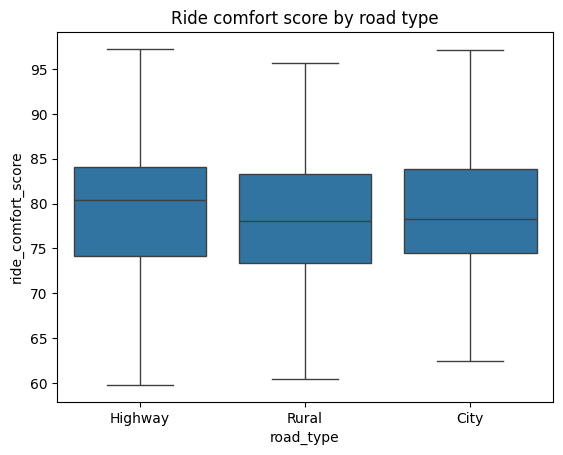

In [131]:
sns.boxplot(
    x='road_type',
    y='ride_comfort_score',
    data=data)
plt.title('Ride comfort score by road type')
plt.show()